In [1]:

import pandas as pd
import matplotlib.pyplot as plt


In [2]:
 #1. Load
df = pd.read_excel("/Users/sunitakumar/Desktop/New_data/marketing_analytics/RFM _practice.xlsx", usecols=["Customer", "Date", "Amount"])
today = df["Date"].max()

In [3]:
#2. Build R, F, M
rfm = df.groupby("Customer").agg(
    R=("Date", lambda x: (today - x.max()).days),   # days since last purchase
    F=("Date", "count"),                            # number of purchases
    M=("Amount", "sum"),                            # total spend
)

In [4]:
rfm

,R,F,M
Customer,,,
1,61,15,937
2,35,20,1390
3,32,19,1337
4,11,22,1549
5,203,13,792
...,...,...,...
4996,72,17,1242
4997,129,21,1243
4998,410,17,986


In [5]:
# 3. Score 1-5 by quintile
rfm["R_score"] = pd.qcut(rfm["R"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["F"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["M"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM"] = (rfm["R_score"].astype(str) + rfm["F_score"].astype(str)
              + rfm["M_score"].astype(str))
rfm["Score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

In [6]:
rfm

,R,F,M,R_score,F_score,M_score,RFM,Score
Customer,,,,,,,,
1,61,15,937,3,1,1,311,5
2,35,20,1390,4,3,4,434,11
3,32,19,1337,4,2,3,423,9
4,11,22,1549,5,4,4,544,13
5,203,13,792,1,1,1,111,3
...,...,...,...,...,...,...,...,...
4996,72,17,1242,2,2,3,223,7
4997,129,21,1243,1,3,3,133,7
4998,410,17,986,1,2,1,121,4


In [11]:
# 4. Segment 
def segment(row):
    r, f = row["R_score"], row["F_score"]
    if r >= 4 and f >= 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal"
    if r >= 4:
        return "New Customers"
    if r == 3:
        return "Needs Attention"
    if f >= 4:
        return "Can't Lose"
    if f == 3:
        return "At Risk"
    return "Lost"
 
 
rfm["Segment"] = rfm.apply(segment, axis=1)

In [12]:
rfm

,R,F,M,R_score,F_score,M_score,RFM,Score,Segment
Customer,,,,,,,,,
1,61,15,937,3,1,1,311,5,Needs Attention
2,35,20,1390,4,3,4,434,11,Loyal
3,32,19,1337,4,2,3,423,9,New Customers
4,11,22,1549,5,4,4,544,13,Champions
5,203,13,792,1,1,1,111,3,Lost
...,...,...,...,...,...,...,...,...,...
4996,72,17,1242,2,2,3,223,7,Lost
4997,129,21,1243,1,3,3,133,7,At Risk
4998,410,17,986,1,2,1,121,4,Lost


In [8]:

# 5. Summary
summary = rfm.groupby("Segment").agg(
    Customers=("Score", "count"),
    Avg_Recency=("R", "mean"),
    Avg_Frequency=("F", "mean"),
    Avg_Spend=("M", "mean"),
    Revenue=("M", "sum"),
).sort_values("Revenue", ascending=False)
summary["Pct_Customers"] = 100 * summary["Customers"] / len(rfm)
summary["Pct_Revenue"] = 100 * summary["Revenue"] / rfm["M"].sum()
 
print("=" * 72)
print("RFM ANALYSIS")
print(f"{len(df):,} transactions | {len(rfm):,} customers | "
      f"${rfm['M'].sum():,.0f} revenue | snapshot {today.date()}")
print("=" * 72)
print(summary.round(1).to_string())
 
print("\nACTION PRIORITY")
for seg, action in [
    ("Champions", "reward and keep - your best customers"),
    ("Can't Lose", "urgent win-back - high value, gone quiet"),
    ("At Risk", "re-engage before they churn"),
    ("New Customers", "onboard and build the second purchase"),
    ("Lost", "low priority - cheap reactivation only"),
]:
    if seg in summary.index:
        row = summary.loc[seg]
        print(f"  {seg:<16} {row['Customers']:>5.0f} customers  "
              f"${row['Revenue']:>10,.0f}  ->  {action}")

RFM ANALYSIS
100,000 transactions | 5,000 customers | $6,508,940 revenue | snapshot 2018-10-06
                 Customers  Avg_Recency  Avg_Frequency  Avg_Spend  Revenue  Pct_Customers  Pct_Revenue
Segment                                                                                               
Loyal                  936         35.7           22.2     1451.6  1358657           18.7         20.9
Champions              833         15.7           24.9     1622.1  1351236           16.7         20.8
Lost                  1106        145.7           16.1     1042.7  1153250           22.1         17.7
Can't Lose             542        118.1           24.6     1599.1   866710           10.8         13.3
New Customers          796         16.1           16.5     1071.6   852978           15.9         13.1
At Risk                348        127.4           20.5     1331.1   463206            7.0          7.1
Needs Attention        439         49.3           16.2     1054.4   462903       

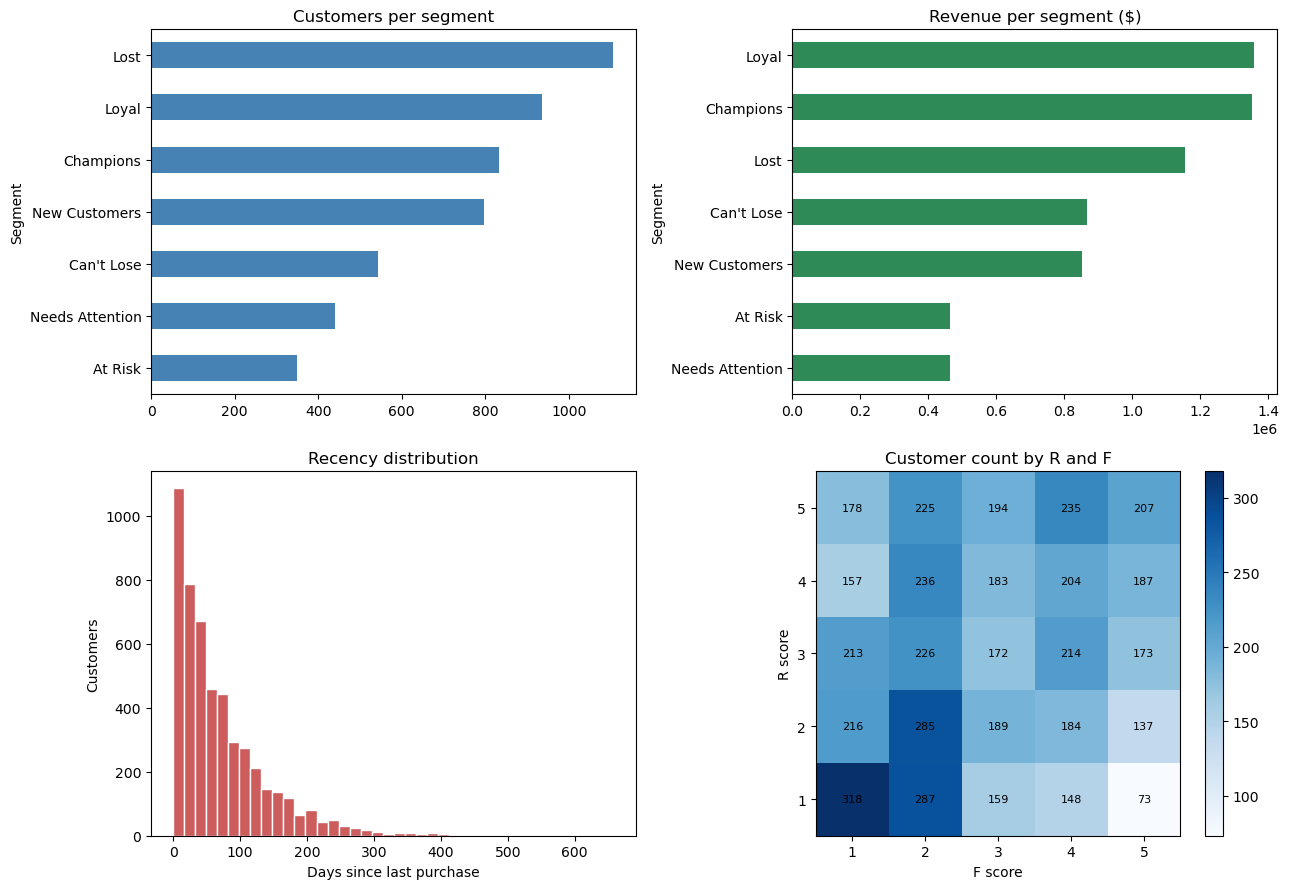

In [9]:

# 6. Charts 
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
 
summary["Customers"].sort_values().plot.barh(ax=ax[0, 0], color="steelblue")
ax[0, 0].set_title("Customers per segment")
 
summary["Revenue"].sort_values().plot.barh(ax=ax[0, 1], color="seagreen")
ax[0, 1].set_title("Revenue per segment ($)")
 
ax[1, 0].hist(rfm["R"], bins=40, color="indianred", edgecolor="white")
ax[1, 0].set_title("Recency distribution")
ax[1, 0].set_xlabel("Days since last purchase")
ax[1, 0].set_ylabel("Customers")
 
heat = rfm.pivot_table(index="R_score", columns="F_score",
                       values="M", aggfunc="count").sort_index(ascending=False)
im = ax[1, 1].imshow(heat, cmap="Blues")
ax[1, 1].set_xticks(range(5), [1, 2, 3, 4, 5])
ax[1, 1].set_yticks(range(5), [5, 4, 3, 2, 1])
ax[1, 1].set_xlabel("F score")
ax[1, 1].set_ylabel("R score")
ax[1, 1].set_title("Customer count by R and F")
for i in range(5):
    for j in range(5):
        ax[1, 1].text(j, i, heat.iloc[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax[1, 1])
 
plt.tight_layout()
plt.show()

In [10]:
# 7. Save
with pd.ExcelWriter("rfm_analysis.xlsx") as w:
    rfm.to_excel(w, sheet_name="Customers")
    summary.round(1).to_excel(w, sheet_name="Segments")
print("\nSaved rfm_analysis.xlsx")


Saved rfm_analysis.xlsx
